In [1]:
import pandas as pd
import bt as bt
import yfinance as yf
import matplotlib
import datetime as dt
import numpy as np
from matplotlib.ticker import PercentFormatter
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from io import StringIO
%matplotlib inline
plt.style.use("dark_background")

In [2]:
inicio = dt.date(2010, 1, 1)
final = dt.date(2024, 10, 31)

start = "2010-1-1"
end = "2024-10-31"

In [3]:
# Verificar o tipo da coluna antes de aplicar replace

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

url = 'https://www.fundamentus.com.br/resultado.php'

driver.get(url)
local_tabela = '/html/body/div[1]/div[2]/table'
elemento = driver.find_element("xpath", local_tabela)
html_tabela = elemento.get_attribute('outerHTML')
tabela = pd.read_html(StringIO(html_tabela), thousands = ".")[0]

tabela = tabela.set_index("Papel")


# Função para garantir que substituímos apenas nas colunas de string
def clean_column(col):
    # Verifica se a coluna é do tipo 'object' (strings)
    if col.dtype == 'object':
        # Substitui os valores "%" e ","
        col = col.str.replace("%", "", regex=False)
        col = col.str.replace(".", "", regex=False)
        col = col.str.replace(",", ".", regex=False)
        # Após as substituições, converte para tipo numérico (float), forçando erros para NaN
        col = pd.to_numeric(col, errors='coerce')
    return col

# Aplicando a limpeza nas colunas de strings
for col in tabela.columns:
    tabela[col] = clean_column(tabela[col])

# Filtrando e ordenando os dados
tabela = tabela[['Cotação', 'EV/EBIT', 'ROIC', 'ROE', 'P/L', 'Liq.2meses']]
tabela = tabela[tabela['Liq.2meses'] > 10000000]
tabela = tabela[tabela['EV/EBIT'] > 0]
tabela = tabela[tabela['ROE'] > 0]
tabela = tabela[tabela['P/L'] < 40]
tabela = tabela[tabela['ROIC'] > 3]

# Rankeando os ativos com base nos melhores EVEBIT e ROIC
tabela['ranking_ev_ebit'] = tabela['EV/EBIT'].rank(ascending=True)
tabela['ranking_PL'] = tabela['P/L'].rank(ascending=True)
tabela['ranking_roic'] = tabela['ROIC'].rank(ascending=False)
tabela['ranking_roe'] = tabela['ROE'].rank(ascending=False)
tabela['ranking_total'] = tabela['ranking_ev_ebit'] + tabela['ranking_roic'] + tabela['ranking_roe'] + tabela['ranking_PL']
tabela = tabela.sort_values('ranking_total')

driver.quit()

In [4]:
tabela = tabela.head(10)
tickers = tabela.index
tickers

Index(['PLPL3', 'CMIN3', 'LEVE3', 'SBSP3', 'BEEF3', 'CMIG4', 'KEPL3', 'PSSA3',
       'BRFS3', 'POMO4'],
      dtype='object', name='Papel')

In [5]:
tickers = [acao + '.SA' for acao in tickers]
tickers

['PLPL3.SA',
 'CMIN3.SA',
 'LEVE3.SA',
 'SBSP3.SA',
 'BEEF3.SA',
 'CMIG4.SA',
 'KEPL3.SA',
 'PSSA3.SA',
 'BRFS3.SA',
 'POMO4.SA']

In [6]:
precos = yf.download(tickers, start, end)["Adj Close"]
# Remover ou preencher valores NaN
precos = precos.dropna()  # Remove linhas com NaN

precos

[                       0%                       ]Failed to get ticker 'BEEF3.SA' reason: Expecting value: line 1 column 1 (char 0)
[**********            20%                       ]  2 of 10 completedFailed to get ticker 'BRFS3.SA' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  10 of 10 completed

10 Failed downloads:
['LEVE3.SA', 'CMIG4.SA', 'PSSA3.SA', 'POMO4.SA', 'KEPL3.SA', 'CMIN3.SA', 'PLPL3.SA', 'SBSP3.SA']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
['BEEF3.SA', 'BRFS3.SA']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


Ticker,BEEF3.SA,BRFS3.SA,CMIG4.SA,CMIN3.SA,KEPL3.SA,LEVE3.SA,PLPL3.SA,POMO4.SA,PSSA3.SA,SBSP3.SA
Date,,,,,,,,,,


In [7]:
ibov = yf.download("^BVSP", start = precos.index[0], end = "2024-10-31")['Adj Close']
df = ibov

df["retorno_ibov"] = ibov.pct_change().values
df["retorno_ibov"] = (1 + df["retorno_ibov"]).cumprod() - 1
df.dropna(inplace=True)
df = df.reindex(precos.index, method='ffill')

df

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# Baixando dados ajustados
data = yf.download(tickers, start='2010-01-01', end='2024-10-31')['Adj Close']

# Criando a estratégia
carteira_plot = bt.Strategy('carteira_plot', [
    bt.algos.RunMonthly(),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    bt.algos.Rebalance()
])

# Criando o backtest
teste = bt.Backtest(carteira_plot, data)

# Executando o backtest
res = bt.run(teste)

[*********************100%***********************]  10 of 10 completed
100%|██████████| 1/1 [00:00<00:00,  1.49it/s]


In [ ]:
#comando para permitir que os gráficos sejam mostrados

plt.ioff()

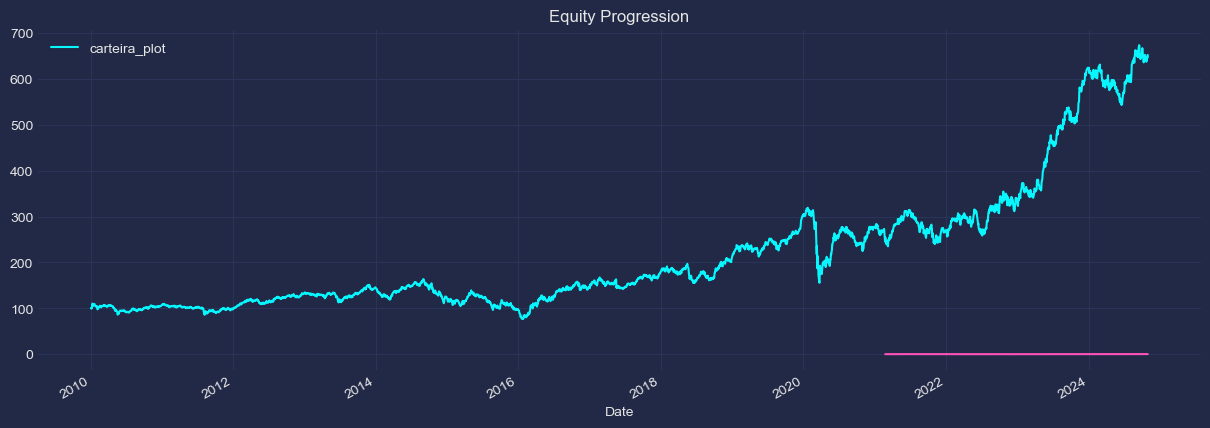

In [ ]:
# plotando a curva de rentabilidade da carteira
res.plot();
df['retorno_ibov'].plot();
plt.show()

In [ ]:
# Plotando o resultado
plt.figure(figsize=(14, 7))
plt.plot(res, label='MODELO')
plt.plot(data['retorno_ibov'], label='Ibovespa')
plt.title(f'Retorno Acumulado: Estratégia de Médias Móveis vs {ticker}')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend(loc='best')
plt.show()

TypeError: unhashable type: 'Result'

In [ ]:
# estatísticas consolidadas
#res.display()

In [ ]:
#rebalanceamento = bt.Strategy('Rebalanceamento',
#                              [bt.algos.RunMonthly(run_on_end_of_period=True),
#                               bt.algos.SelectAll(),
#                               bt.algos.WeighSpecified(),
#                               bt.algos.Rebalance()])

In [ ]:
#ver como puxar os pesos diferentes automaticamente

#buy_hold = bt.Strategy('BuyHold', 
#                   [ bt.algos.RunOnce(),
#                     bt.algos.SelectAll(),
#                     bt.algos.WeighSpecified(bbas3sa=0.033988, bbdc4sa=0.025153, cple6sa=0.198313, irbr3sa=0.003, itsa4sa=0.023996,itub4sa=0.045475, klbn4sa=0.205830, petr4sa=0.189004,vale3sa=0.027203, wege3sa=0.245390),
#                     bt.algos.Rebalance()]
#                    )

In [ ]:
#testbh = bt.Backtest(buy_hold, data)
#res = bt.run(testbh)

#testr = bt.Backtest(buy_hold, data)
#res = bt.run(testr)

#capital = 100000

In [ ]:
#bt1 = bt.Backtest(rebalanceamento, 
#                  data)
#bt2 = bt.Backtest(buy_hold, 
#                  data)

In [ ]:
#resultados = bt.run(bt1, bt2)

In [ ]:
#def plot_security_weights(resultados, name):
#    result.get_security_weights().plot(figsize=(10, 6))
#    plt.title(f'{name} Portfolio Weights')
#    plt.xlabel('Date')
#    plt.ylabel('Weight')
#    plt.legend(title='Asset', bbox_to_anchor=(1.05, 1), loc='upper left')
#    plt.grid()
#    plt.show()

In [ ]:
#plt.ioff()

In [ ]:
# Plotando o resultado
plt.figure(figsize=(14, 7))
plt.plot(data['bt1'], label='BT2')
plt.plot(data['bt2'], label='BT1')
plt.plot(data['retorno_ibov'], label='Ibovespa')
plt.title(f'Retorno Acumulado: Estratégia de Médias Móveis vs {ticker}')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend(loc='best')
plt.show()

In [ ]:
resultados.display()

Stat                 Rebalanceamento    BuyHold
-------------------  -----------------  ----------
Start                2017-07-30         2017-07-30
End                  2024-10-30         2024-10-30
Risk-free rate       0.00%              0.00%

Total Return         502.67%            478.76%
Daily Sharpe         1.18               1.12
Daily Sortino        1.81               1.73
CAGR                 28.10%             27.39%
Max Drawdown         -44.17%            -44.21%
Calmar Ratio         0.64               0.62

MTD                  -1.20%             -1.03%
3m                   4.74%              5.61%
6m                   11.57%             11.82%
YTD                  15.05%             15.74%
1Y                   31.38%             32.95%
3Y (ann.)            24.88%             23.63%
5Y (ann.)            25.35%             24.79%
10Y (ann.)           -                  -
Since Incep. (ann.)  28.10%             27.39%

Daily Sharpe         1.18               1.12
Daily Sort

In [ ]:
resultados.get_security_weights()

,bbas3sa,bbdc4sa,cple6sa,irbr3sa,itsa4sa,itub4sa,klbn4sa,petr4sa,vale3sa,wege3sa
2017-07-30 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-07-31 00:00:00+00:00,0.033980,0.025142,0.198312,0.002807,0.023994,0.045461,0.205829,0.189001,0.027185,0.245385
2017-08-01 00:00:00+00:00,0.034550,0.025347,0.198199,0.002807,0.024672,0.046728,0.204999,0.185831,0.026868,0.247106
2017-08-02 00:00:00+00:00,0.035199,0.025164,0.196717,0.002753,0.024441,0.046238,0.206223,0.187401,0.026355,0.246676
2017-08-03 00:00:00+00:00,0.035908,0.025496,0.195665,0.002780,0.024719,0.046754,0.206822,0.187119,0.026342,0.245523
...,...,...,...,...,...,...,...,...,...,...
2024-10-24 00:00:00+00:00,0.033095,0.026417,0.194736,0.002970,0.023417,0.045163,0.201749,0.189190,0.025669,0.254902
2024-10-25 00:00:00+00:00,0.033134,0.026054,0.193895,0.002779,0.023196,0.044692,0.204862,0.190657,0.026563,0.251475
2024-10-28 00:00:00+00:00,0.032904,0.026391,0.193313,0.002953,0.023339,0.045008,0.203339,0.189381,0.026921,0.253770
2024-10-29 00:00:00+00:00,0.032650,0.025956,0.195091,0.002930,0.023140,0.044439,0.201458,0.188576,0.026772,0.256314


In [ ]:
resultados.get_transactions()

price  quantity
Date                      Security                      
2017-07-31 00:00:00+00:00 bbas3sa     9.131910    3721.0
                          bbdc4sa    11.650463    2158.0
                          cple6sa     1.459790  135850.0
                          irbr3sa   215.954483      13.0
                          itsa4sa     4.438382    5406.0
...                                        ...       ...
2024-09-30 00:00:00+00:00 itub4sa    36.074162    -154.0
                          klbn4sa     4.129418    2827.0
                          petr4sa    36.009998    1899.0
                          vale3sa    63.509998    -252.0
                          wege3sa    54.389999    -944.0

[855 rows x 2 columns]